In [ ]:
!pip install control optuna matplotlib numpy scipy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from control import tf, feedback, step_response, step_info
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

# Suppress Optuna's verbose logging for cleaner output
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Mass-spring-damper parameters
m = 1.0   # mass (kg)
c = 10.0  # damping coefficient (N*s/m)
k = 20.0  # spring constant (N/m)

# Plant transfer function: G(s) = 1 / (ms^2 + cs + k)
G = tf([1], [m, c, k])
print("Plant transfer function:")
print(G)

Plant transfer function:
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         1
  ---------------
  s^2 + 10 s + 20


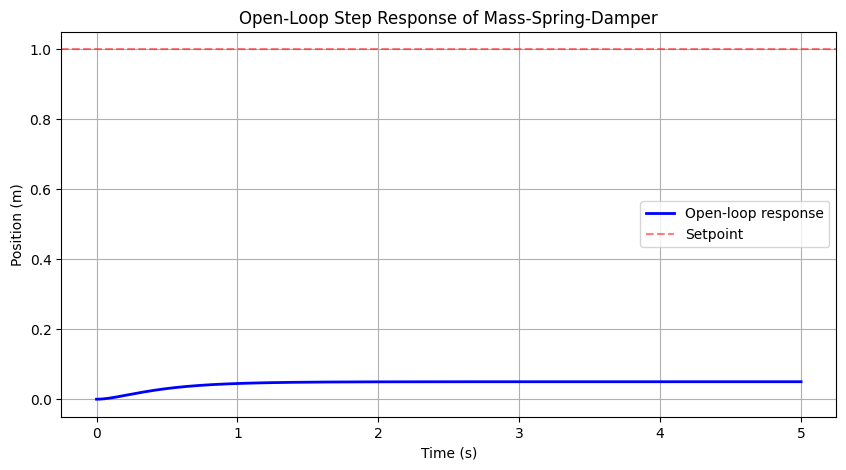

In [ ]:
t = np.linspace(0, 5, 1000)
t_ol, y_ol = step_response(G, t)

plt.figure(figsize=(10, 5))
plt.plot(t_ol, y_ol, 'b-', linewidth=2, label='Open-loop response')
plt.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Setpoint')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Open-Loop Step Response of Mass-Spring-Damper')
plt.legend()
plt.grid(True)
plt.show()

# Notice: steady-state value is 1/k = 0.05, far from 1
# This is why we need a controller

In [ ]:
def evaluate_pid(Kp, Ki, Kd, N, plant, t_sim=5.0, n_points=1000):
    """
    Simulates closed-loop with filtered PID:
    C(s) = Kp + Ki/s + Kd*s/(s/N + 1)

    Combined: C(s) = [(Kp + Kd*N)s^2 + (Ki + Kp*N)s + Ki*N] / [s(s + N)]
    """
    # Filtered PID transfer function
    num = [Kp + Kd*N, Ki + Kp*N, Ki*N]
    den = [1, N, 0]
    C = tf(num, den)

    T = feedback(C * plant, 1)

    t = np.linspace(0, t_sim, n_points)
    try:
        t, y = step_response(T, t)
    except Exception:
        return None

    if np.any(np.isnan(y)) or np.max(np.abs(y)) > 10:
        return None

    setpoint = 1.0
    error = setpoint - y

    peak = np.max(y)
    overshoot = max(0, (peak - setpoint) / setpoint * 100)

    settling_band = 0.02 * setpoint
    settled_indices = np.where(np.abs(error) > settling_band)[0]
    settling_time = t[settled_indices[-1]] if len(settled_indices) > 0 else 0

    itae = np.trapz(t * np.abs(error), t)
    sse = abs(error[-1])

    return {
        'overshoot': overshoot,
        'settling_time': settling_time,
        'itae': itae,
        'sse': sse,
        't': t,
        'y': y
    }

In [ ]:
def objective(trial):
    Kp = trial.suggest_float('Kp', 0.1, 200)
    Ki = trial.suggest_float('Ki', 0.0, 200)
    Kd = trial.suggest_float('Kd', 0.0, 50)
    N  = trial.suggest_float('N', 1, 200)

    result = evaluate_pid(Kp, Ki, Kd, N, G)

    if result is None:
        return 1e6

    w_overshoot = 1.0
    w_settling = 5.0
    w_itae = 2.0
    w_sse = 50.0

    cost = (w_overshoot * result['overshoot'] +
            w_settling * result['settling_time'] +
            w_itae * result['itae'] +
            w_sse * result['sse'])

    return cost

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=150, show_progress_bar=True)

print(f"Best gains: Kp={study.best_params['Kp']:.3f}, "
      f"Ki={study.best_params['Ki']:.3f}, "
      f"Kd={study.best_params['Kd']:.3f}, "
      f"N={study.best_params['N']:.3f}")

  0%|          | 0/150 [00:00<?, ?it/s]

/tmp/ipykernel_20041/4230206181.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  itae = np.trapz(t * np.abs(error), t)


Best gains: Kp=114.177, Ki=199.692, Kd=8.190, N=121.892


--- Performance Metrics ---
Overshoot:        0.00 %
Settling time:    0.260 s
ITAE:             0.0172
Steady-state err: 0.00000


/tmp/ipykernel_20041/4230206181.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  itae = np.trapz(t * np.abs(error), t)


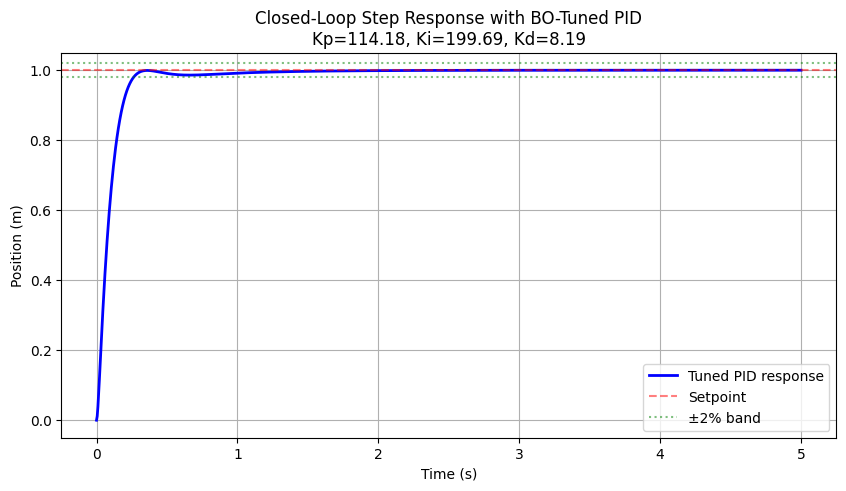

In [ ]:
best = study.best_params
result = evaluate_pid(best['Kp'], best['Ki'], best['Kd'], best['N'], G)

print("--- Performance Metrics ---")
print(f"Overshoot:        {result['overshoot']:.2f} %")
print(f"Settling time:    {result['settling_time']:.3f} s")
print(f"ITAE:             {result['itae']:.4f}")
print(f"Steady-state err: {result['sse']:.5f}")

plt.figure(figsize=(10, 5))
plt.plot(result['t'], result['y'], 'b-', linewidth=2, label='Tuned PID response')
plt.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Setpoint')
plt.axhline(y=1.02, color='g', linestyle=':', alpha=0.5, label='±2% band')
plt.axhline(y=0.98, color='g', linestyle=':', alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title(f'Closed-Loop Step Response with BO-Tuned PID\n'
          f'Kp={best["Kp"]:.2f}, Ki={best["Ki"]:.2f}, Kd={best["Kd"]:.2f}')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# How the cost evolved during optimization
fig1 = plot_optimization_history(study)
fig1.show()

# Which parameters mattered most
fig2 = plot_param_importances(study)
fig2.show()

In [ ]:
import nbformat

def remove_broken_widgets(notebook_path):
    # Load the notebook using your current nbformat version
    with open(notebook_path, 'r', encoding='utf-8') as f:
        nb = nbformat.read(f, as_version=4)

    # Check if 'widgets' exists in the top-level metadata and delete it
    if 'widgets' in nb.metadata:
        del nb.metadata['widgets']
        print(f"Successfully removed 'widgets' metadata from {notebook_path}")
    else:
        print(f"No 'widgets' key found in the metadata of {notebook_path}")

    # Save the cleaned notebook back to disk
    with open(notebook_path, 'w', encoding='utf-8') as f:
        nbformat.write(nb, f)

# Replace with the path to your notebook
remove_broken_widgets("First Test.ipynb")

FileNotFoundError: [Errno 2] No such file or directory: 'First Test.ipynb'

In [ ]:
from google.colab import files

# This will prompt you to select the file from your computer/OneDrive
# After uploading, the file will be in the current directory
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" to the current directory.')
    # You can now call your function with this filename
    # remove_broken_widgets(filename)